### Importando bibliotecas Numpy, Skimage e Matplotlib

In [1]:
import numpy as np
from skimage import io, data, transform, util
import matplotlib.pyplot as plt
# Define para mostrar 2 casas decimais
np.set_printoptions(formatter={'float': '{:0.2f}'.format})

# Questões sobre Numpy

<p> 1. Crie um array NumPy unidimensional de 10 elementos inteiros aleatórios entre 0 e 100. Calcule e exiba: média (<i>mean</i>), mediana (<i>median</i>), desvio padrão (<i>std</i>), valor mínimo (<i>min</i>) e máximo (<i>max</i>).</p>

In [33]:
v = np.random.randint(low=0, high=100, size=10)
print(v)
print(f'Média: {np.mean(v)}')
print(f'Mediana: {np.median(v)}')
print(f'Desvio padrão: {np.std(v)}')
print(f'Valor mínimo: {np.min(v)}')
print(f'Valor máximo: {np.max(v)}')

[29 96 45 87 30 39 52 48 74 69]
Média: 56.9
Mediana: 50.0
Desvio padrão: 22.22813532440362
Valor mínimo: 29
Valor máximo: 96


<p>2. Crie uma matriz $5 \times 5$ preenchida com zeros. Em seguida, preencha a borda externa (primeira e última linha, primeira e última coluna) com o valor 1.</p>

In [36]:
m = np.zeros((5,5), dtype=int)
m[0, :] = 1
m[-1, :] = 1
m[:, 0] = 1
m[:, -1] = 1
print(m)

[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]


<p>3. Crie uma matriz identidade $6 \times 6$. Substitua todos os elementos da diagonal secundária pelo número 9. Não utilizar laços de repetição</p>

In [5]:
matriz = np.eye(6)
print(matriz)
linha = np.arange(0, 6)
coluna = np.arange(5, -1, -1)
matriz[linha, coluna] = 9
print(matriz)

[[1.00 0.00 0.00 0.00 0.00 0.00]
 [0.00 1.00 0.00 0.00 0.00 0.00]
 [0.00 0.00 1.00 0.00 0.00 0.00]
 [0.00 0.00 0.00 1.00 0.00 0.00]
 [0.00 0.00 0.00 0.00 1.00 0.00]
 [0.00 0.00 0.00 0.00 0.00 1.00]]
[[1.00 0.00 0.00 0.00 0.00 9.00]
 [0.00 1.00 0.00 0.00 9.00 0.00]
 [0.00 0.00 1.00 9.00 0.00 0.00]
 [0.00 0.00 9.00 1.00 0.00 0.00]
 [0.00 9.00 0.00 0.00 1.00 0.00]
 [9.00 0.00 0.00 0.00 0.00 1.00]]


<p>4. Crie uma matriz $6 \times 6$ com valores aleatórios entre 0 e 1. Extraia e exiba:
<ul>
<li>A primeira linha</li>
<li>A última coluna</li>
<li>O subarray central $2 \times 2$</li>
<li>Todos os elementos maiores que 0.5</li>
<ul></p>

In [7]:
M = np.random.random((6,6))
print(M)
print(f'Primeira linha: {M[0,:]}')
print(f'Última coluna: {M[:, -1]}')
print(f'Subarray central 2x2: {M[2:4, 2:4]}')
print(f'Elementos maiores que 0.5: {M[M>0.5]}')

[[0.04 0.85 0.71 0.94 0.24 0.87]
 [0.20 0.71 0.68 0.86 0.70 0.98]
 [0.65 0.38 0.38 0.46 0.79 0.77]
 [0.12 0.01 0.33 0.48 0.16 0.71]
 [0.58 0.55 0.21 0.52 0.23 0.53]
 [0.14 0.19 0.48 0.77 0.35 0.70]]
Primeira linha: [0.04 0.85 0.71 0.94 0.24 0.87]
Última coluna: [0.87 0.98 0.77 0.71 0.53 0.70]
Subarray central 2x2: [[0.38 0.46]
 [0.33 0.48]]
Elementos maiores que 0.5: [0.85 0.71 0.94 0.87 0.71 0.68 0.86 0.70 0.98 0.65 0.79 0.77 0.71 0.58
 0.55 0.52 0.53 0.77 0.70]


<p>5. Crie uma matriz $10 \times 10$ com valores inteiros aleatórios. Encontre e exiba a posição (linha, coluna) do maior valor da matriz. Estudar as funçoes <i>argmax</i>, <i>unravel_index</i> e <i>ravel_multi_index</i></p>

In [17]:
v = np.random.randint(low=0, high=10, size=(10, 10))
print(v)
pos = np.argmax(v)
print(pos)
row, col = np.unravel_index(pos, (10, 10))
print(f'Posição do maior valor: ({row}, {col})')


[[1 5 3 3 6 8 6 1 2 5]
 [7 5 9 3 0 9 0 1 0 3]
 [6 7 7 8 8 8 9 4 4 0]
 [3 1 4 2 3 5 1 1 3 5]
 [9 8 0 5 2 9 2 2 1 1]
 [7 1 8 8 9 5 5 2 3 6]
 [6 6 9 1 0 6 7 6 9 6]
 [9 9 8 5 8 6 6 2 6 6]
 [9 9 0 1 5 3 3 4 0 0]
 [4 7 0 0 0 0 5 8 2 4]]
12
Posição do maior valor: (1, 2)


<p>6. Crie uma matriz $5 \times 5$ com valores inteiros de 1 a 25 (linha por linha). Utilizando fatiamento, extraia e exiba:
<ul>
<li>A submatriz formada pelas linhas 1 a 3 e colunas 1 a 3</li>
<li>A submatriz formada pelas linhas pares (0,2,4) e todas as colunas</li>
<li>Os elementos da diagonal principal</li>
</ul></p>

In [21]:
m = np.arange(1,26).reshape((5,5))
print(f'Matriz original =\n {m}')

m1 = m[1:4, 1:4]
print(f'\nSubmatriz =\n {m1}')

m2 = m[0::2, :]
print(f'\nSubmatriz =\n {m2}')

indice = np.arange(5)
m3 = m[indice,indice]
print(f'\nDiagonal principal =\n {m3}')

Matriz original =
 [[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

Submatriz =
 [[ 7  8  9]
 [12 13 14]
 [17 18 19]]

Submatriz =
 [[ 1  2  3  4  5]
 [11 12 13 14 15]
 [21 22 23 24 25]]

Diagonal principal =
 [ 1  7 13 19 25]


<p>7. Crie uma matriz $6 \times 6$ com valores aleatórios. Calcule e exiba:
<ul>
<li>A média de cada linha</li>
<li>A média de cada coluna</li>
<li>A soma de todos os elementos</li>
<li>O produto de todos os elementos (use <i>np.prod<i>)</li>
</ul></p>

In [25]:
m = np.random.randint(low=0, high=100, size=(6,6))
print(f'\nMatriz original: \n{m}')
media_linha = np.mean(m, axis=1)
print(f'\nMédia de cada linha: \n{media_linha}')
media_coluna = np.mean(m, axis=0)
print(f'\nMédia de cada coluna: \n{media_coluna}')
soma = np.sum(m)
print(f'\nsoma = {soma}')
produto = np.prod(m)
print(f'\nproduto = {produto}')


Matriz original: 
[[69 96  3 80 51 55]
 [99 98 86 87 89 57]
 [43 89 39 84 92  0]
 [83 86 90 25 56 58]
 [80 77 43 46 81 63]
 [68 15 93 40 14  4]]

Média de cada linha: 
[59.00 86.00 57.83 66.33 65.00 39.00]

Média de cada coluna: 
[73.67 76.83 59.00 60.33 63.83 39.50]

soma = 2239

produto = 0


<p>8. Broadcasting é um mecanismo do NumPy que permite realizar operações matemáticas entre arrays de formatos diferentes sem a necessidade de copiar dados ou usar loops explícitos. O NumPy automaticamente "estica" o array menor para que ele tenha o mesmo formato do maior, desde que as dimensões sejam compatíveis (iguais ou uma delas seja igual a 1). Por exemplo, ao somar um vetor a uma matriz, o vetor é automaticamente somado a cada linha da matriz; ao somar uma constante a um array, a constante é transmitida para todos os elementos. Isso torna o código mais eficiente, econômico em memória e muito mais limpo, eliminando a necessidade de repetir manualmente os valores.</p>

<p>Crie uma matriz $3 \times 3$ com valores aleatórios e um vetor de 3 elementos. Utilizando broadcasting, some o vetor a cada linha da matriz. Em seguida, transforme o vetor em um vetor coluna (formato $3\times1$) e realize a soma entre a matriz e esse vetor coluna.</p>

In [32]:
m = np.random.randint(low=0, high=10, size=(3,3))
print(f'\nMatriz original: \n{m}')
v = np.random.randint(low=0, high=10, size=(3))
print(f'\nVetor: {v}')

s = m + v
print(f'\nSoma com o vetor linha\n{s}')

s2 = m + v.reshape(3, 1)
print(f'\nSoma com o vetor coluna\n{s2}')


Matriz original: 
[[4 0 2]
 [2 7 6]
 [5 2 6]]

Vetor: [0 9 9]

Soma com o vetor linha
[[ 4  9 11]
 [ 2 16 15]
 [ 5 11 15]]

Soma com o vetor coluna
[[ 4  0  2]
 [11 16 15]
 [14 11 15]]


9. Crie o seguinte padrão sem codificação, usando apenas funções numpy.

[a,b,c] -> [a,a,a,b,b,b,c,c,c,a,b,c,a,b,c,a,b,c]

Dica: ver funções <i>repeat()</i> e <i>tile()</i>

In [48]:
a = np.array([1,2,3])
b = np.concatenate([np.repeat(a,3),np.tile(a, 3)])
print(b)

[1 1 1 2 2 2 3 3 3 1 2 3 1 2 3 1 2 3]


10. Dado um array 1-D, transformar em negativos todos os número entre 3 e 8

In [51]:
Z = np.arange(11)
print(Z)

Z[(Z > 3) & (Z < 9)] *= -1
print(Z)

[ 0  1  2  3  4  5  6  7  8  9 10]
[ 0  1  2  3 -4 -5 -6 -7 -8  9 10]


# Questões sobre imagens

In [52]:
from skimage import io, data, transform, color,util
import matplotlib.pyplot as plt
from scipy import ndimage

In [53]:
def show(img_list, caption_list, Axis=False):
    n = len(img_list)
    f, ax = plt.subplots(1,n, figsize=(10+5*(n-1),10))
    for i in range(n):
        ax[i].imshow(img_list[i], cmap='gray')
        ax[i].set_title(caption_list[i])
        if not Axis:
            ax[i].set_axis_off()

11. Crie a função que troque os quadrantes de uma imagem dividida em quatro partes

In [57]:
def troca(img):
  h, w = img.shape[:2]
  mh, mw = h // 2, w // 2

  Q1 = img[:mh, :mw]
  Q2 = img[:mh, mw:]
  Q3 = img[mh:, :mw]
  Q4 = img[mh:, mw:]

  linha_cima = np.concatenate([Q4, Q3], axis=1)
  linha_baixo = np.concatenate([Q2, Q1], axis=1)
  nimg = np.concatenate([linha_cima, linha_baixo], axis=0)

  return nimg

In [55]:
img = color.rgb2gray(data.chelsea())
print(img.shape)

(300, 451)


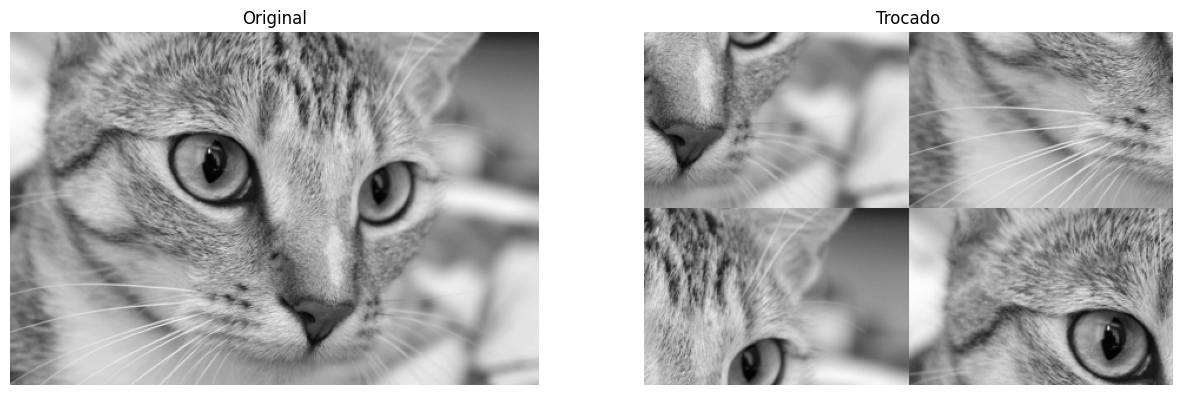

In [58]:
# delete: retorna um novo array com sub-arrays ao longo de um eixo removidos.
img = np.delete(img, -1, axis=1) # a imagem agora tem um número par de colunas
nimg = troca(img)
show([img, nimg],['Original', 'Trocado'])

## Transformações geométricas

<p>Testar as funções de transformação geométrica:
rotação, escala, translação, cisalhamento em imagens.

*   rotação: *transform.rotate(...)*
*   escala: *transform.rescale(...)*
*   traslação: *transform.AffineTransform(...)* e *transform.warp(..)*
*   cisalhamento: *transform.AffineTransform(...)* e *transform.warp(..)*

<ol>
  <li> <b>skimage.transform.rotate</b>(image, angle, resize=False, center=None, order=None, mode='constant', cval=0, clip=True, preserve_range=False):
  Rotate image by a certain angle around its center.
      
  Parameters
  <ul>
  <li> image: ndarray. Input image.</li>
  <li> angle: float. Rotation angle in degrees in counter-clockwise direction.</li>
  <li> resize: bool, optional. Determine whether the shape of the output image will be automatically calculated, so the complete rotated image exactly fits. Default is False. </li>
  <li> center: iterable of length 2. The rotation center. If center=None, the image is rotated around its center, i.e. center=(cols / 2 - 0.5, rows / 2 - 0.5). Please note that this parameter is (cols, rows), contrary to normal skimage ordering. </li>
  </ul>
  Result
  <ul>
  <li> rotated: ndarray. Rotated version of the input.</li>
  </ul>
      
  <li> <b>skimage.transform.rescale</b>(image, scale, channel_axis=None): Scale image by a certain factor.
      
  Parameters
    <ul>
    <li> image: ndarray. Input image.</li>
    <li> scale: {float, tuple of floats}. Scale factors. S</li>
    <li> channel_axis: int or None, optional. If None, the image is assumed to be a grayscale (single channel) image. Otherwise, this parameter indicates which axis of the array corresponds to channels </li>
    </ul>
  Result
    <ul>
    <li> rotated: ndarray. Scaled version of the input.</li>
    </ul>

  <li><b>skimage.transform.AffineTransform</b>(matrix=None, scale=None, rotation=None, shear=None, translation=None, dimensionality=2)</li>
    
  Parameters
  <ul>
  <li> matrix: (D+1, D+1) array, optional. Homogeneous transformation matrix. </li>
  <li> scale: {s as float or (sx, sy) as array, list or tuple}, optional.  Scale factor(s). </li>
  <li> rotation: float, optional. Rotation angle in counter-clockwise direction as radians. Only available for 2D.</li>
  <li> shear: float, optional. Shear angle in counter-clockwise direction as radians. Only available for 2D.</li>
  <li> translation: (tx, ty) as array, list or tuple, optional. Translation parameters. Only available for 2D.</li>
  </ul>

  <li><b> skimage.transform.warp</b>(image, inverse_map, map_args={}, output_shape=None, order=None, mode='constant', cval=0.0, clip=True, preserve_range=False): Warp an image according to a given coordinate transformation.</li>
    
  Parameters
  <ul>
  <li> image: ndarray. Input image. </li>
  <li> inverse_map: transformation object. Inverse coordinate map, which transforms coordinates in the output images into their corresponding coordinates in the input image. </li>
  <li> map_args: dict, optional. Keyword arguments passed to inverse_map.</li>
  <li> output_shape: tuple (rows, cols), optional. Shape of the output image generated. By default the shape of the input image is preserved. </li>
  <li> order: int, optional. The order of interpolation. The order has to be in the range 0-5: (0: Nearest-neighbor, 1: Bi-linear (default), 2: Bi-quadratic, 3: Bi-cubic, 4: Bi-quartic, 5: Bi-quintic)</li>
  </ul>
  Result
  <ul>
  <li> warped: double ndarray. The warped input image.</li>
  </ul>   
</ol>
</p>


# Questão 12
<p>Realizar as seguintes transformações geoméricas:
  <ul>
  <li>Rotaçao de 23 graus. A imagem resultante deve incluir a imagem completa</li>
  <li>Reescalar a imagem para a metade</li>
  <li>Trasladar em 50 pixels en linhas e 100 pixels em colunas. Usar a combinação das funções <i>AffineTransform</i> e <i>warp</i></li>
  <li>Aplicar o efeito de cisalhamento (shear) em $\frac{\pi}{8}$ graus</li>
  </ul>
</p>

(512, 512, 3)


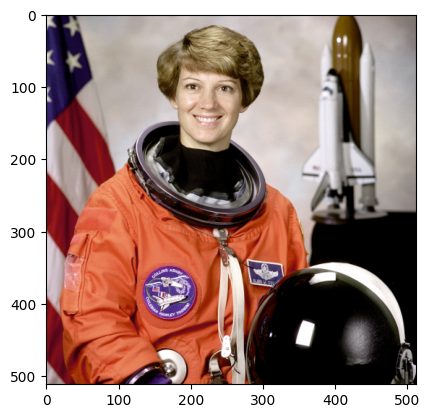

In [73]:
img = data.astronaut()
plt.imshow(img)
print(img.shape)

In [75]:
rotacao = transform.rotate(img, 23, resize=True, center=None, order=None, mode='constant', cval=0, clip=True, preserve_range=False)
escala = transform.rescale(img, 0.5, anti_aliasing=True, channel_axis=2)
matriz_traslacao = transform.AffineTransform(translation=(100, 50))
traslacao = transform.warp(img, matriz_traslacao)
matriz_shear = transform.AffineTransform(shear=np.pi/8)
shear = transform.warp(img, matriz_shear)

Text(0.5, 1.0, 'Shear')

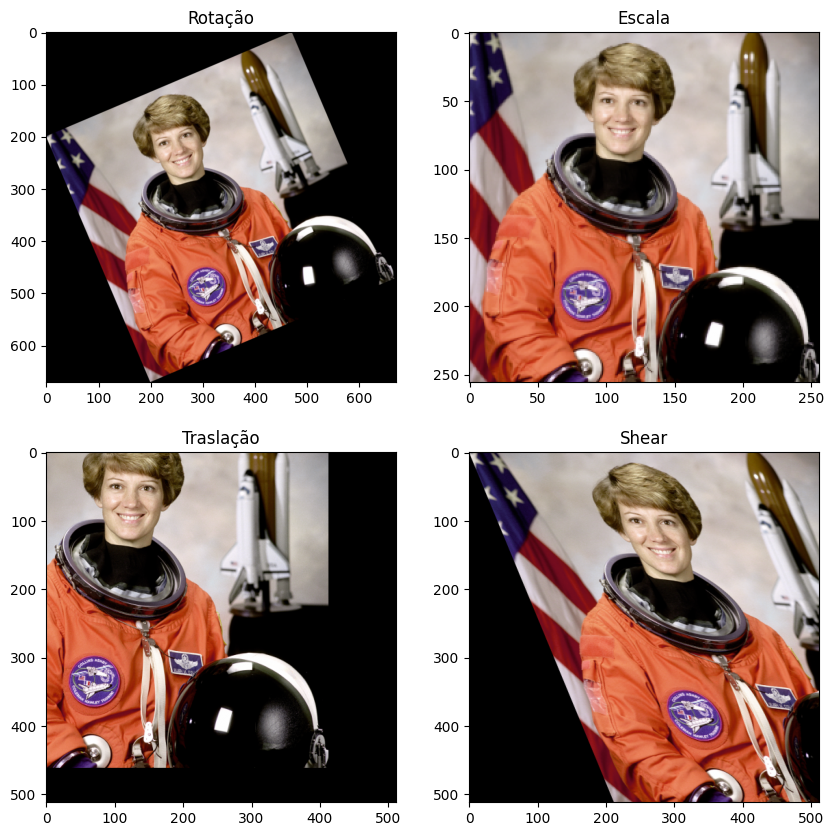

In [76]:
f, ax = plt.subplots(2,2, figsize=(10,10))
ax[0,0].imshow(rotacao)
ax[0,0].set_title('Rotação')
ax[0,1].imshow(escala)
ax[0,1].set_title('Escala')
ax[1,0].imshow(traslacao)
ax[1,0].set_title('Traslação')
ax[1,1].imshow(shear)
ax[1,1].set_title('Shear')

## Questão 11

Dadas duas imagens, misturar ambas imagens gerando uma terceira. A forma de misturar é a seguinte: a terceira imagem estará formada pelas linhas e colunas impares da primeira imagem e as pares da segunda imagem.

<table><tr>
<td> <img src="https://drive.google.com/uc?id=1k0FG4pT6WMjFeG-V63OBXNS7_CvfY5m_" alt="Drawing" style="width: 250px;"/> </td>
<td> <img src="https://drive.google.com/uc?id=15yt6Tt5liol_jKWbkfcNXV-SoeaY706s" alt="Drawing" style="width: 250px;"/> </td>
<td> <img src="https://drive.google.com/uc?id=1FboaUm6DeM-HsHRXQfyt1tPgl6rLkGQK" alt="Drawing" style="width: 250px;"/> </td>
</tr></table>

In [92]:
def merge(img1, img2):
  nimg = np.zeros_like(img1)

  nimg[1::2, 1::2] = img1[1::2, 1::2]
  nimg[0::2, 0::2] = img2[0::2, 0::2]
  nimg[1::2, 0::2] = img1[1::2, 0::2]
  nimg[0::2, 1::2] = img2[0::2, 1::2]

  return nimg


In [93]:
lenna = io.imread('https://drive.google.com/uc?id=1k0FG4pT6WMjFeG-V63OBXNS7_CvfY5m_')
clown = io.imread('https://drive.google.com/uc?id=15yt6Tt5liol_jKWbkfcNXV-SoeaY706s')

print(f'Tamanho imagem Lenna: {lenna.shape}')
print(f'Tamanho imagem clown: {clown.shape}')

new_clown = util.img_as_ubyte(color.rgba2rgb(clown))
merged = merge(lenna, new_clown)

Tamanho imagem Lenna: (512, 512, 3)
Tamanho imagem clown: (512, 512, 4)


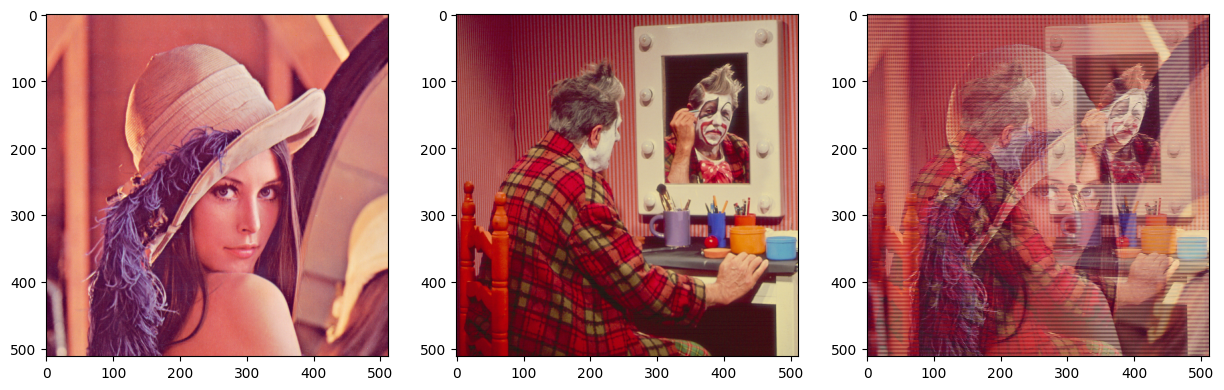

In [94]:
f, ax = plt.subplots(1,3, figsize=(15,10))
ax[0].imshow(lenna)
ax[1].imshow(clown)
ax[2].imshow(merged)